# Simulate a simple noisy tipping system with slow forcing

$$dx = [x - x^3 + \mu(t)] dt + \sigma dW_t$$

- $x - x^3$ gives a double-well landscape
- $\mu(t)$ slowly drifts and deforms the wells
- As $\mu$ increases, one attractor loses stability and the trajectory is pushed toward a "tipping point"

In [2]:
import numpy as np
from ripser import ripser
import matplotlib.pyplot as plt

def simulate_tipping(
    T=4000,
    dt=0.02,
    x0=-1.0,
    mu0=-0.8,
    mu1=0.8,
    sigma=0.12,
    seed=0
):
    rng = np.random.default_rng(seed)
    n = int(T)
    x = np.zeros(n)
    mu = np.linspace(mu0, mu1, n)
    x[0] = x0

    sqrt_dt = np.sqrt(dt)

    for i in range(n - 1):
        drift = x[i] - x[i]**3 + mu[i]
        x[i + 1] = x[i] + drift * dt + sigma * sqrt_dt * rng.normal()

    t = np.arange(n) * dt
    return t, x, mu

# Delay Embeddings

In [3]:
def delay_embedding(series, delay=5, dim=3):
    n = len(series) - (dim - 1) * delay
    if n <= 0:
        raise ValueError("Time series too short")
    return np.array([
        [series[i + j * delay] for j in range(dim)]
        for i in range(n)
    ])

# Compute Persistent-homology features for one window

Let $X$ be a topological space. The singular chain complex is
$$\cdots \xrightarrow{\partial_3} C_2(X) \xrightarrow{\partial_2} C_1(X) \xrightarrow{\partial_1} C_0(X) \to 0$$

The 0-th homology group is defined as:
$$H_0(X) = \ker(\partial_0) / \text{im}(\partial_1) = C_0(X) / \text{im}(\partial_1)$$
For a path-connected space $X$, $H_0(X) \cong \mathbb{Z}$.


The 1-st homology group is defined as:
$$H_1(X) = \ker(\partial_1) / \text{im}(\partial_2)$$
It represents 1-dimensional cycles modulo 1-dimensional boundaries.
For a connected space $X$, $H_1(X)$ is the abelianization of the fundamental group:
$$H_1(X) \cong \pi_1(X, x_0)^{ab}$$

- H0 total persistence  -> clustering / spread
- H1 total persistence  -> loopiness / recurrent geometry
- max H1 persistence    -> strength of dominant loop

In [4]:
def pers_feat(point_cloud, maxdim=1, q=0.9):
    """Compute persistence features from a point cloud."""
    dgms = ripser(point_cloud, maxdim=maxdim)["dgms"]

    h0 = dgms[0]
    h1 = dgms[1] if len(dgms) > 1 else np.empty((0, 2))

    # H0
    if len(h0) > 0:
        finite_h0 = h0[np.isfinite(h0[:, 1])]
        pers0 = finite_h0[:, 1] - finite_h0[:, 0] if len(finite_h0) > 0 else np.array([])
        h0_total = np.sum(pers0) if len(pers0) > 0 else 0.0
        h0_max   = np.max(pers0) if len(pers0) > 0 else 0.0
    else:
        h0_total = 0.0
        h0_max   = 0.0

    # H1
    if len(h1) > 0:
        pers1 = h1[:, 1] - h1[:, 0]
        h1_total = np.sum(pers1)
        h1_max   = np.max(pers1)

        # adaptive threshold only "strong" loops
        thresh = np.quantile(pers1, q)
        h1_strong_total = np.sum(pers1[pers1 >= thresh])
        h1_strong_count = np.sum(pers1 >= thresh)
    else:
        pers1 = np.array([])
        h1_total = 0.0
        h1_max = 0.0
        h1_strong_total = 0.0
        h1_strong_count = 0

    return {
        "h0_total": h0_total,
        "h0_max": h0_max,
        "h1_total": h1_total,
        "h1_max": h1_max,
        "h1_strong_total": h1_strong_total,
        "h1_strong_count": h1_strong_count,
        "dgms": dgms,
    }

# Sliding Window for Topology Over Time

In [7]:
def windowed_topo(series, times, control=None, window_size=300, step=30, delay=5, embed_dim=3):
    centers = []
    mu_centers = []
    h0_total = []
    h0_max = []
    h1_total = []
    h1_max = []
    h1_strong_total = []
    h1_strong_count = []
    saved_diagrams = []

    for start in range(0, len(series) - window_size + 1, step):
        stop = start + window_size
        window = series[start:stop]
        pc = delay_embedding(window, delay=delay, dim=embed_dim)
        feats = pers_feat(pc, maxdim=1)

        centers.append(times[start + window_size // 2])

        if control is not None:
            mu_centers.append(control[start + window_size // 2])

        h0_total.append(feats["h0_total"])
        h0_max.append(feats["h0_max"])
        h1_total.append(feats["h1_total"])
        h1_max.append(feats["h1_max"])
        h1_strong_total.append(feats["h1_strong_total"])
        h1_strong_count.append(feats["h1_strong_count"])
        saved_diagrams.append(feats["dgms"])

    out = {
        "time": np.array(centers),
        "h0_total": np.array(h0_total),
        "h0_max": np.array(h0_max),
        "h1_total": np.array(h1_total),
        "h1_max": np.array(h1_max),
        "h1_strong_total": np.array(h1_strong_total),
        "h1_strong_count": np.array(h1_strong_count),
        "dgms": saved_diagrams,
    }

    if control is not None:
        out["mu"] = np.array(mu_centers)

    return out

# Run the Model

In [8]:
t, x, mu = simulate_tipping(
    T=5000,
    dt=0.02,
    x0=-1.0,
    mu0=-0.9,
    mu1=0.9,
    sigma=0.10,
    seed=3
)

results = windowed_topo(
    x, t, mu,
    window_size=350,
    step=40,
    delay=6,
    embed_dim=3
)

# Compare with Variance/Autocorrelation Baseline

In [9]:
def lag1_autocorr(y):
    y0 = y[:-1] - np.mean(y[:-1])
    y1 = y[1:] - np.mean(y[1:])
    denom = np.sqrt(np.sum(y0**2) * np.sum(y1**2))
    return np.sum(y0 * y1) / denom if denom > 0 else np.nan

# Early Warning Signals (EWS): variance and lag-1 autocorrelation
def windowed_ews(series, times, mus, window_size=300, step=30):
    centers = []
    mu_centers = []
    variances = []
    ac1 = []

    for start in range(0, len(series) - window_size + 1, step):
        stop = start + window_size
        window = series[start:stop]
        centers.append(times[start + window_size // 2])
        mu_centers.append(mus[start + window_size // 2])
        variances.append(np.var(window))
        ac1.append(lag1_autocorr(window))

    return {
        "time": np.array(centers),
        "mu": np.array(mu_centers),
        "variance": np.array(variances),
        "ac1": np.array(ac1),
    }

ews = windowed_ews(x, t, mu, window_size=350, step=40)

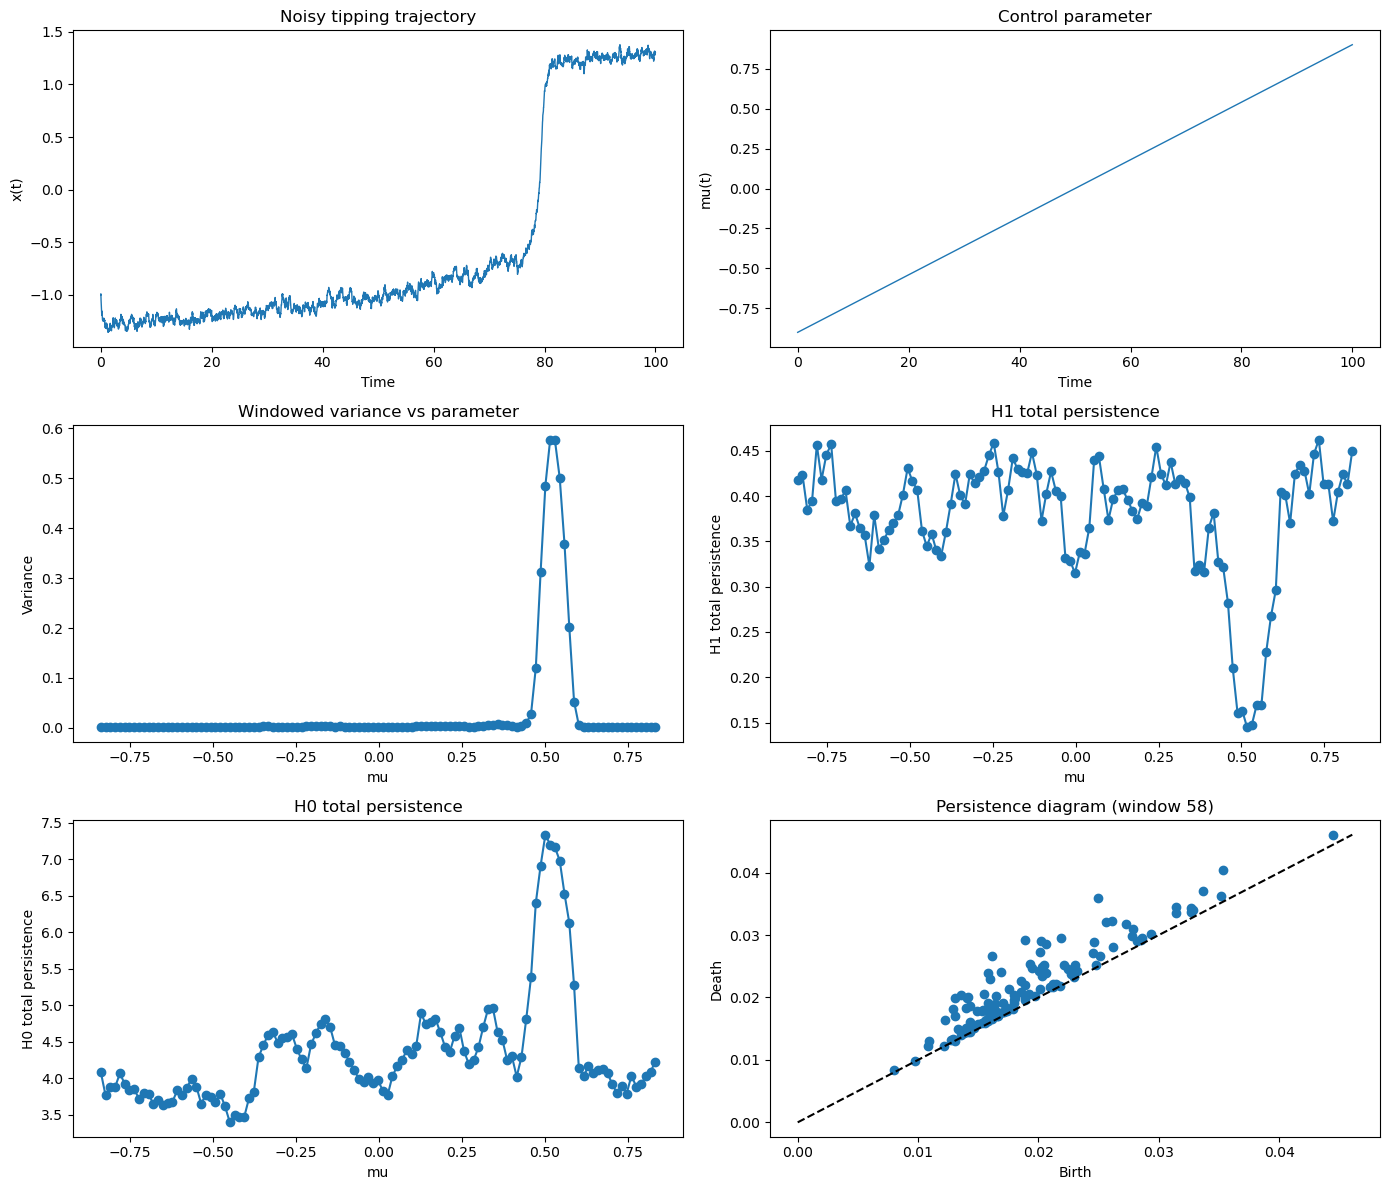

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# time series
axes[0, 0].plot(t, x, lw=1)
axes[0, 0].set_title("Noisy tipping trajectory")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("x(t)")

# forcing parameter
axes[0, 1].plot(t, mu, lw=1)
axes[0, 1].set_title("Control parameter")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("mu(t)")

# variance EWS
axes[1, 0].plot(ews["mu"], ews["variance"], "o-")
axes[1, 0].set_title("Windowed variance vs parameter")
axes[1, 0].set_xlabel("mu")
axes[1, 0].set_ylabel("Variance")

# H1 total persistence
axes[1, 1].plot(results["mu"], results["h1_total"], "o-")
axes[1, 1].set_title("H1 total persistence")
axes[1, 1].set_xlabel("mu")
axes[1, 1].set_ylabel("H1 total persistence")

# H0 total persistence
axes[2, 0].plot(results["mu"], results["h0_total"], "o-")
axes[2, 0].set_title("H0 total persistence")
axes[2, 0].set_xlabel("mu")
axes[2, 0].set_ylabel("H0 total persistence")

# persistence diagram for a late window
idx = len(results["dgms"]) // 2
diag_h1 = results["dgms"][idx][1]
axes[2, 1].set_title(f"Persistence diagram (window {idx})")
if len(diag_h1) > 0:
    axes[2, 1].scatter(diag_h1[:, 0], diag_h1[:, 1])
    max_val = np.max(diag_h1)
    axes[2, 1].plot([0, max_val], [0, max_val], "k--")
axes[2, 1].set_xlabel("Birth")
axes[2, 1].set_ylabel("Death")

plt.tight_layout()
plt.show()